# 03 · Time evolution, approximation error, and transpilation

**Question:** Does a compiled evolution circuit implement the intended dynamics,
and what gate cost accompanies a more accurate approximation?

The original notebook appended a `PauliEvolutionGate` and compared transpilation
levels. This version makes its synthesis choice explicit and separates
**evolution-approximation error** from **compilation of an already synthesized
circuit**. The comparisons use the same small Hamiltonian as Notebook 02.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from IPython.display import display
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.quantum_info import Statevector, Operator, state_fidelity
from qiskit.synthesis import LieTrotter, MatrixExponential
from qiskit_portfolio.experiments import (
    BASIS_GATES, SEED, hamiltonian, run_vqe,
    evolution_circuit, evolution_comparison, transpilation_comparison,
)

## 1. Obtain the variational state and an exact dynamics reference

In units with $\hbar=1$, $U(t)=\exp(-itH)$. Here both H coefficients and t are
dimensionless. `scipy.linalg.expm` supplies a dense reference for two qubits.

An exact energy eigenstate changes only by a global phase under its own
Hamiltonian. Its measurement probabilities therefore remain unchanged.
The VQE state is close to that eigenstate, so exact evolution should preserve
its state fidelity to numerical precision.

In [2]:
vqe = run_vqe()
H = hamiltonian()
time = 1.0
reference_unitary = expm(-1j * time * H.to_matrix())
exact_evolved_state = Statevector(reference_unitary @ vqe.state.data)
survival = float(state_fidelity(vqe.state, exact_evolved_state))
print(f'Fidelity to the initial VQE state after exact evolution: {survival:.12f}')
assert survival > 1 - 1e-8

Fidelity to the initial VQE state after exact evolution: 1.000000000000


## 2. Specify how the evolution gate becomes elementary operations

`PauliEvolutionGate` represents the exact operator. Its default synthesis is
a single-step first-order Lie-Trotter product formula. For noncommuting terms,
that compiled circuit generally approximates the operator.

**Subtlety:** In the tested Qiskit version, direct statevector evaluation can
use an unsynthesized gate's exact matrix. To measure product-formula error, call
`synthesis.synthesize(gate)` first and evaluate the resulting circuit.
Otherwise the approximation may never enter the calculation.

`MatrixExponential` supplies an exact small-system baseline. It relies on dense
matrices and is not a scalable Hamiltonian-simulation algorithm.

Four-step fidelity to exact evolution: 0.9881690301669788


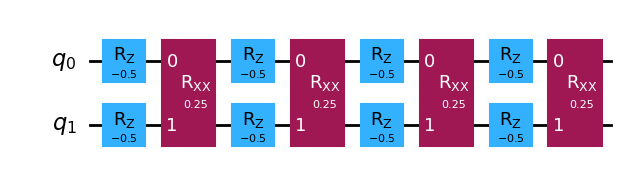

In [3]:
exact_synthesis = MatrixExponential()
exact_gate = PauliEvolutionGate(H, time=time, synthesis=exact_synthesis)
exact_steps = exact_synthesis.synthesize(exact_gate)
assert Operator(exact_steps).equiv(Operator(reference_unitary))

trotter_synthesis = LieTrotter(reps=4)
trotter_gate = PauliEvolutionGate(H, time=time, synthesis=trotter_synthesis)
trotter_steps = trotter_synthesis.synthesize(trotter_gate)
approximate_circuit = vqe.circuit.compose(trotter_steps)
approximate_state = Statevector.from_instruction(approximate_circuit)
print('Four-step fidelity to exact evolution:', float(state_fidelity(exact_evolved_state, approximate_state)))
display(trotter_steps.draw('mpl', fold=50))
plt.close('all')  # Prevent a second automatic inline display.

## 3. Measure the approximation-versus-cost tradeoff

Compare 1, 4, 16, and 64 Lie-Trotter repetitions at fixed t. Each entry is
synthesized first and transpiled at **level 1** into `rz`, `sx`, `x`, and `cx`.
Report state infidelity $1-|\langle\psi_{exact}|\psi_{circuit}\rangle|^2$ and gate cost.
This is a comparison for this initial state and time, not a worst-case operator
error bound. More repetitions improve this example's accuracy and increase cost.

In [4]:
evolution_rows = evolution_comparison(vqe.circuit, time=time)
print('Method                reps     fidelity       infidelity      depth    CX')
for row in evolution_rows:
    reps_label = '-' if row['repetitions'] is None else str(row['repetitions'])
    print(f"{row['method']:22s} {reps_label:>4s}  {row['fidelity']:.10f}  {row['infidelity']:.3e}  {row['depth']:8d}  {row['cx_count']:4d}")
assert evolution_rows[0]['fidelity'] > 1 - 1e-10
assert evolution_rows[-1]['infidelity'] < evolution_rows[1]['infidelity']

Method                reps     fidelity       infidelity      depth    CX
matrix exponential        -  1.0000000000  4.441e-16        22     3
Lie-Trotter               1  0.6601142325  3.399e-01        14     3
Lie-Trotter               4  0.9881690302  1.183e-02        38     9
Lie-Trotter              16  0.9992835446  7.165e-04       134    33
Lie-Trotter              64  0.9999553088  4.469e-05       518   129


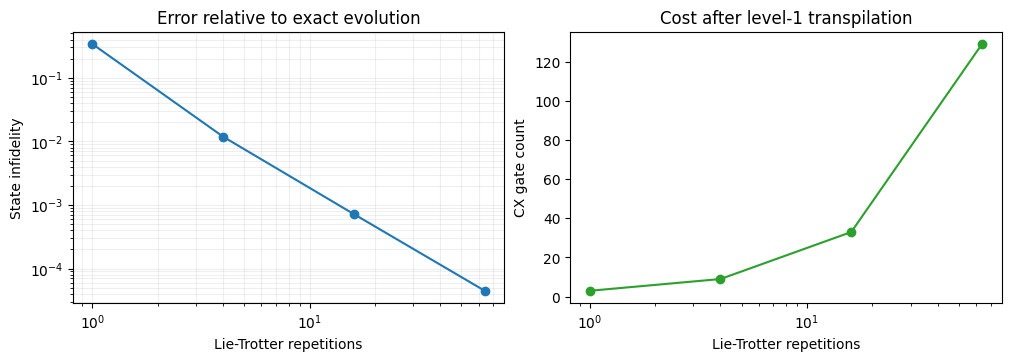

In [5]:
approximate_rows = evolution_rows[1:]
repetitions = [row['repetitions'] for row in approximate_rows]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)
axes[0].loglog(repetitions, [row['infidelity'] for row in approximate_rows], 'o-')
axes[0].set(xlabel='Lie-Trotter repetitions', ylabel='State infidelity', title='Error relative to exact evolution')
axes[0].grid(alpha=0.2, which='both')
axes[1].plot(repetitions, [row['cx_count'] for row in approximate_rows], 'o-', color='tab:green')
axes[1].set_xscale('log')
axes[1].set(xlabel='Lie-Trotter repetitions', ylabel='CX gate count', title='Cost after level-1 transpilation')
plt.show()

## 4. Compare optimization levels for a fixed synthesized circuit

Transpilation rewrites a circuit to meet a gate basis and other target
constraints. Optimization levels 0–3 select increasing effort, but a higher
level is not guaranteed to produce a smaller circuit for every case.

Here we freeze a four-step Lie-Trotter circuit before transpiling, fixing the
approximation across all levels. `Operator.equiv` checks the full unitary up
to global phase. It verifies that compilation preserves the synthesized
circuit; it does not turn the Trotter approximation into exact evolution.

Level   depth   gate count   CX count   unitary preserved
    0      46           74          9   True
        gate types: {'rz': 47, 'sx': 18, 'cx': 9}
    1      38           59          9   True
        gate types: {'rz': 32, 'sx': 18, 'cx': 9}
    2      13           18          2   True
        gate types: {'rz': 10, 'sx': 6, 'cx': 2}
    3      13           18          2   True
        gate types: {'rz': 10, 'sx': 6, 'cx': 2}


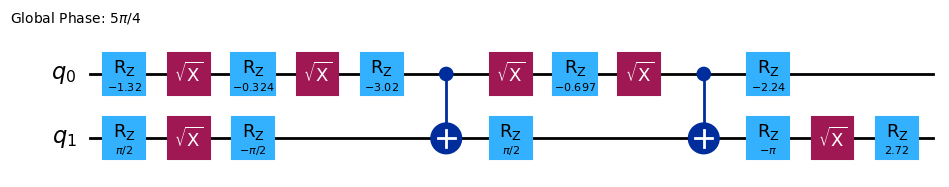

In [6]:
fixed_circuit = evolution_circuit(vqe.circuit, time=time, reps=4)
compilation_rows = transpilation_comparison(fixed_circuit)
print('Level   depth   gate count   CX count   unitary preserved')
for row in compilation_rows:
    print(f"{row['optimization_level']:5d} {row['depth']:7d} {row['gate_count']:12d} {row['cx_count']:10d}   {row['unitary_equivalent']}")
    print('        gate types:', row['count_ops'])
assert all(row['unitary_equivalent'] for row in compilation_rows)

level_three = transpile(
    fixed_circuit, basis_gates=BASIS_GATES,
    optimization_level=3, seed_transpiler=SEED,
)
display(level_three.draw('mpl', fold=50))
plt.close('all')  # Prevent a second automatic inline display.

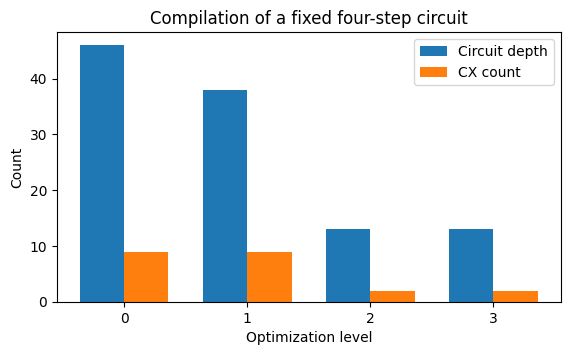

In [7]:
levels = np.arange(4)
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.bar(levels - 0.18, [row['depth'] for row in compilation_rows], width=0.36, label='Circuit depth')
ax.bar(levels + 0.18, [row['cx_count'] for row in compilation_rows], width=0.36, label='CX count')
ax.set(xlabel='Optimization level', ylabel='Count', title='Compilation of a fixed four-step circuit', xticks=levels)
ax.legend()
plt.show()

## Interpretation and limits

Circuit depth counts sequential layers, not physical elapsed time. A composite
evolution gate may look shallow before decomposition, yet require many elementary
gates. The same-unitary check protects correctness when comparing those circuits.

There is no device coupling map, calibration, gate-duration model, or noise model
in this comparison. Basis translation alone does not guarantee that a circuit
meets a particular backend's complete instruction-set requirements.
Both dense references and full-unitary checks are appropriate for this two-qubit
exercise and become expensive for larger systems.

**References:** [PauliEvolutionGate](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.PauliEvolutionGate),
[LieTrotter](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.synthesis.LieTrotter),
[Transpiler optimization levels](https://quantum.cloud.ibm.com/docs/en/guides/set-optimization).